<font size=10>**TASK 2 - SENTIMENT ANALYSIS**</font> <a class="anchor" id='title'></a> 

**Bachelor's in Data Science - NOVA IMS (25/26)**

**Project**: *Straining the great southern Melting Pot*

**Group 8**
- Beatriz Marques 20231605
- David Carrilho 20231693
- Duarte Fernandes 20231619
- Filipe Caçador 20231707
- Mariana Calais-Pedro 20231641

<font color='red'>*«notebook description»*</font>

**Question**: *How strong is the relationship between the polarity of a comments and its score?*

<font color='#BFD72' size=6>**TABLE OF CONTENTS**</font> <a class="anchor" id='toc'></a> 
- [1. Imports](#1)
- [2. Data](#2)
- [3. Sentiment Analysis](#3)
    - [3.1 Specific Data Preparation](#3_1)
    - [3.2 Model Implementation](#3_2)
        - [3.2.1 VADER Sentiment Analysis](#3_2_1)
            - [3.2.1.1 Compound Score of Entire Review](#3_2_1_1)
            - [3.2.1.2 Average Compound Score Across Sentences](#3_2_1_2)
            - [3.2.1.3 Correlation Between Full Review and Sentence-Level](#3_2_1_3)
        - [3.2.2 TextBlob Sentiment Analysis](#3_2_2)
            - [3.2.2.1 Polarity Score of Entire Review](#3_2_2_1)
            - [3.2.2.2 Average Polarity Across Sentences](#3_2_2_2)
            - [3.2.2.3 Correlation Between Full Review and Sentence-Level](#3_2_2_3)
    - [3.3 Model Evaluation](#3_3)
    - [3.4 Answer the Question](#3_4)

# <font color='#BFD72F' size=6>**1. Imports**</font> <a class="anchor" id="1"></a>

[Back to TOC](#toc)

In [2]:
import warnings
%load_ext autoreload
%autoreload 2

warnings.filterwarnings('ignore')

In [4]:
pip install vaderSentiment

Note: you may need to restart the kernel to use updated packages.


In [5]:
import sys
import os

import pandas as pd

from scipy.stats import pearsonr

from nltk.tokenize import PunktSentenceTokenizer
from sklearn.preprocessing import MinMaxScaler

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Get the absolute path of the source_code folder
source_code_path = os.path.abspath('../source')

# Add the source_code folder to sys.path
if source_code_path not in sys.path:
    sys.path.append(source_code_path)

from my_utils import *
from visualizations import *
from general_preprocessing import *
from sentiment_prep import *
from evaluation import *

# <font color='#BFD72F' size=6>**2. Data**</font> <a class="anchor" id="2"></a>
  
[Back to TOC](#toc)

In [7]:
dataset_original = load_dataset('../data/atlanta_restaurant_slice_2023.csv')

In [8]:
dataset_original.head()

,title,categoryName,website,url,reviewsCount,stars,text
0,The Optimist,Seafood restaurant,https://www.theoptimistrestaurant.com/,https://www.google.com/maps/place/The+Optimist...,3349,5.0,"One word amazing!! The red fish, halibut, fr..."
1,The Optimist,Seafood restaurant,https://www.theoptimistrestaurant.com/,https://www.google.com/maps/place/The+Optimist...,3349,5.0,First time here and the food is great and the ...
2,The Optimist,Seafood restaurant,https://www.theoptimistrestaurant.com/,https://www.google.com/maps/place/The+Optimist...,3349,5.0,I recently had the pleasure of dining at Optim...
3,The Optimist,Seafood restaurant,https://www.theoptimistrestaurant.com/,https://www.google.com/maps/place/The+Optimist...,3349,5.0,Beautiful atmosphere and delicious food. All o...
4,The Optimist,Seafood restaurant,https://www.theoptimistrestaurant.com/,https://www.google.com/maps/place/The+Optimist...,3349,5.0,We had a wonderful dinner at the Optimist. Our...


In [9]:
dataset_original.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53566 entries, 0 to 53565
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   title         53566 non-null  object 
 1   categoryName  53566 non-null  object 
 2   website       50600 non-null  object 
 3   url           53566 non-null  object 
 4   reviewsCount  53566 non-null  int64  
 5   stars         53566 non-null  float64
 6   text          53566 non-null  object 
dtypes: float64(1), int64(1), object(5)
memory usage: 2.9+ MB


| 🏷️ **Column Name** | 📝 **Description** |
|:-------------------|:-------------------|
|**title** | Name of the restaurant |
|**categoryName** | Labels that describe the restaurant's cuisine type |
|**website** | URL of the restaurant's webpage |
|**url** | URL of the restaurant's Google Maps page |
|**reviewsCount** | Total number of reviews for the restaurant at the time of scraping |
|**stars** | Customer rating (1 to 5) |
|**text** | Text of the review |

In [10]:
dataset = dataset_original.copy()

# <font color='#BFD72F' size=6>**3. Sentiment Analysis**</font> <a class="anchor" id="3"></a>
  
[Back to TOC](#toc)

From the data exploration stage (Notebooks 01 and 02), several key insights emerged:

(*01_data_understtanding.ipynb*)
- The average value of the `overall` rating is **4.05**, which is very close to the maximum possible score of 5, indicating generally high customer satisfaction.

(*02_general_data_prep.ipynb*)
- The majority of reviews in the `text` column are **short**, consisting of **1–2 sentences**. The `num_sentences` distribution supports this: 
    - median = $2$
    - $75^{th}$ percentile = $4$
    - maximum = $43$

    suggesting a few exceptionally long reviews.

--

- Among the 20 most frequent tokens in the `atlanta_restaurants` dataset, **XX** and **XX** are the only terms that are *not* stopwords, highlighting the predominance of common words in customer reviews.

## <font color='#BFD72F' size=6>3.1 Specific Data Preparation</font> <a class="anchor" id="3_1"></a>
  
[Back to TOC](#toc)

To prepare the raw review text for sentiment analysis, two complementary columns are generated:

1. **`preproc_content`** — full-review preprocessing  
2. **`preproc_sentences`** — sentence-level preprocessing  


<font color='#BFD72F'>**Data Types & Outputs**</font>

| Column | Description |
|--------|-------------|
| **`preproc_content`** | Single processed string representing the full review |
| **`preproc_sentences`** | List of processed sentence strings per review |


<font color='#BFD72F'>**1. Full-Review Preprocessing (`preproc_content`)**</font>

Each full review is processed using the project’s `main_pipeline`, configured to **preserve**:

- casing  
- punctuation  
- stopwords  
- original word forms (no lemmatization)  

This produces **one processed representation per review**, optimized for lexicon-based sentiment tools.


<font color='#BFD72F'>**2. Sentence-Level Preprocessing (`preproc_sentences`)**</font>

1. Reviews are split into sentences using **NLTK’s `PunktSentenceTokenizer`**.  
2. Each sentence is processed through `main_pipeline` with the same preservation settings.  

The result is **a list of processed sentence strings per review**, enabling straightforward computation and aggregation of sentence-level sentiment scores (e.g., mean).

---


<font color='#BFD72F'>**Why Preserve Punctuation, Casing, and Stopwords?**</font>

Lexicon-based tools such as **VADER** and **TextBlob** rely on these features:

- **Punctuation** and **capitalization** signal emphasis and intensity.  
- **Stopwords** include negations and modal verbs that modify sentiment.  
- Over-normalization (lowercasing, removing stopwords, stripping punctuation) can **weaken polarity accuracy**.

Preservation therefore improves alignment with lexicon behavior.


<font color='#BFD72F'>**Benefits**</font>

- **Dual granularity**: enables comparisons between whole-review sentiment and sentence-level aggregation—valuable for mixed-opinion reviews.  
- **Lexicon compatibility**: retained cues (e.g., “not”, “!”, **ALL CAPS**) improve polarity and intensity scores.  
- **Consistency**: using the same pipeline on both levels ensures comparable outputs.


<font color='#BFD72F'>**Limitations & Recommendations**</font>

- **Performance**: if `main_pipeline` is slow, use batching, multiprocessing, or vectorized operations.  
- **Downstream models**: ML models often benefit from a *normalized* pipeline (lowercasing, stopword removal, lemmatization). Compare pipelines.  
- **Mixed reviews**: prefer sentence-level aggregation (mean, weighted mean, attention-based) for long or multi-opinion reviews.  
- **Validation**: assess the effect of these choices by comparing polarity correlations with human labels or star ratings, and by benchmarking against a normalized pipeline.  

In [11]:
dataset["preproc_content"] =\
      dataset["text"].map(lambda content : main_pipeline(content,
                                                            print_output=False,
                                                            no_stopwords=False,
                                                            lowercase=False,
                                                            lemmatized=False,
                                                            no_punctuation=False
                                                            ))

In [12]:
sent_tokenizer = PunktSentenceTokenizer()

dataset["preproc_sentences"] =\
      dataset["text"].map(lambda content : [main_pipeline(sentence,
                                                            print_output=False,
                                                            no_stopwords=False,
                                                            lowercase=False,
                                                            lemmatized=False,
                                                            no_punctuation=False
                                                            ) for sentence in sent_tokenizer.tokenize(content)])

In [13]:
# Follow an example
print("Original Text Sample:\n")
print(dataset[['text']].sample(1, random_state=42).values)
print("\nPreprocessed Content Sample:\n")
print(dataset[['preproc_content']].sample(1, random_state=42).values)
print("\nPreprocessed Sentences Sample:\n")
print(dataset[['preproc_sentences']].sample(1, random_state=42).values)

Original Text Sample:

[['Wife & I visited The Red Eyed Mule. The food was good.  The biscuits are soft, tasty and just right.The service was great. Atmosphere clean and positive. The decorations on wall is very educational. Overall, enjoyed my breakfast experience at Red Eyed Mule. We plan to return.']]

Preprocessed Content Sample:

[['Wife & I visited The Red Eyed Mule . The food was good . The biscuits are soft, tasty and just right.The service was great . Atmosphere clean and positive . The decorations on wall is very educational . Overall, enjoyed my breakfast experience at Red Eyed Mule . We plan to return.']]

Preprocessed Sentences Sample:

[[list(['Wife & I visited The Red Eyed Mule.', 'The food was good.', 'The biscuits are soft, tasty and just right.The service was great.', 'Atmosphere clean and positive.', 'The decorations on wall is very educational.', 'Overall, enjoyed my breakfast experience at Red Eyed Mule.', 'We plan to return.'])]]


In sentiment analysis we intentionally skip the usual feature extraction and vectorization steps of the text‑mining pipeline because lexicon‑based tools (e.g., VADER, TextBlob) operate directly on raw text. Instead, we apply minimal, targeted preprocessing (see `preproc_content` and `preproc_sentences`). Consequently, we move straight to model application (lexicon scoring) rather than building vector representations for downstream models.

## <font color='#BFD72F' size=6>3.2 Model Implementation</font> <a class="anchor" id="3_2"></a>
  
[Back to TOC](#toc)

### <font color='#BFD72F' size=6>3.2.1 VADER Sentiment Analysis</font> <a class="anchor" id="3_2_1"></a>
  
[Back to TOC](#toc)

#### **3.2.1.1 Compound Score of Entire Review** <a class="anchor" id="3_2_1_1"></a>
*Sentiment score computed from the full text of each review.*

In [14]:
vader_scores = dataset["preproc_content"].map(vader_wrapper).apply(pd.Series)
dataset = pd.concat([dataset, vader_scores.add_prefix("content_polarity_vader_")], axis=1)

In [15]:
print("\nReview:\n")
print(dataset[['text']].sample(1, random_state=42).values)

print('\nVader Compound:\n', dataset[['content_polarity_vader_compound']].sample(1, random_state=42).values)
print('\nVader Positive:\n', dataset[['content_polarity_vader_pos']].sample(1, random_state=42).values)
print('\nVader Negative:\n', dataset[['content_polarity_vader_neg']].sample(1, random_state=42).values)
print('\nVader Neutral:\n', dataset[['content_polarity_vader_neu']].sample(1, random_state=42).values)


Review:

[['Wife & I visited The Red Eyed Mule. The food was good.  The biscuits are soft, tasty and just right.The service was great. Atmosphere clean and positive. The decorations on wall is very educational. Overall, enjoyed my breakfast experience at Red Eyed Mule. We plan to return.']]

Vader Compound:
 [[0.9485]]

Vader Positive:
 [[0.257]]

Vader Negative:
 [[0.]]

Vader Neutral:
 [[0.743]]


<font color='#BFD72F'>**Interpretation**</font>

| Metric           | Value    | Description |
|------------------|----------|-------------|
| **Compound**     | 0.9485   | Indicates a strongly positive overall sentiment (range: -1 to +1) |
| **Positive**     | 0.257    | 25.7% of the text reflects positive sentiment |
| **Negative**     | 0.000    | No negative sentiment detected |
| **Neutral**      | 0.743    | 74.3% of the text is neutral or factual |


<font color='#BFD72F'>**Insights**</font>

- The **high compound score** confirms the review is overwhelmingly positive.
- The **positive sentiment** is driven by phrases like “food was good,” “biscuits are soft, tasty and just right,” and “service was great.”
- The **neutral score** is typical for descriptive reviews that include factual observations (e.g., atmosphere and wall decorations).
- The **absence of negative sentiment** reinforces the overall satisfaction expressed by the reviewer.


#### **3.2.1.2 Average Compound Score Across Sentences** <a class="anchor" id="3_2_1_2"></a>
*Mean sentiment score calculated from individual sentence-level analysis.*

In [16]:
mean_vader_scores = dataset["preproc_sentences"].map(vader_wrapper).apply(pd.Series)
dataset = pd.concat([dataset, mean_vader_scores.add_prefix("mean_sentence_polarity_vader_")], axis=1)

In [17]:
print("\nReview:\n")
print(dataset[['text']].sample(1, random_state=42).values)

print("\nAverage Sentence Vader Compound:\n", dataset[['mean_sentence_polarity_vader_compound']].sample(1, random_state=42).values)
print("\nAverage Sentence Vader Positive:\n", dataset[['mean_sentence_polarity_vader_pos']].sample(1, random_state=42).values)
print("\nAverage Sentence Vader Negative:\n", dataset[['mean_sentence_polarity_vader_neg']].sample(1, random_state=42).values)
print("\nAverage Sentence Vader Neutral:\n", dataset[['mean_sentence_polarity_vader_neu']].sample(1, random_state=42).values)


Review:

[['Wife & I visited The Red Eyed Mule. The food was good.  The biscuits are soft, tasty and just right.The service was great. Atmosphere clean and positive. The decorations on wall is very educational. Overall, enjoyed my breakfast experience at Red Eyed Mule. We plan to return.']]

Average Sentence Vader Compound:
 [[0.33127143]]

Average Sentence Vader Positive:
 [[0.262]]

Average Sentence Vader Negative:
 [[0.]]

Average Sentence Vader Neutral:
 [[0.738]]


#### **3.2.1.3 Correlation Between Full Review and Sentence-Level** <a class="anchor" id="3_2_1_3"></a>
*Scores Statistical comparison of both compound scoring approaches.*

In [18]:
pearson_r_vader, p_value_vader = pearsonr(dataset["content_polarity_vader_compound"],dataset["mean_sentence_polarity_vader_compound"])
print(f'Pearson correlation of content wise vader compound with mean sentences vader compound is: {pearson_r_vader}.')

Pearson correlation of content wise vader compound with mean sentences vader compound is: 0.8114668343234341.


This high correlation implies that there is little difference between whole-review and sentence-level scores, likely because most reviews are only one sentence long.

### <font color='#BFD72F' size=6>3.2.2 TextBlob Sentiment Analysis</font> <a class="anchor" id="3_2_2"></a>
  
[Back to TOC](#toc)

#### **3.2.2.1 Polarity Score of Entire Review** <a class="anchor" id="3_2_2_1"></a>
*Sentiment polarity derived from the full review text.*

In [19]:
textblob_scores = dataset["preproc_content"].map(textblob_wrapper).apply(pd.Series)
dataset = pd.concat([dataset, textblob_scores.add_prefix("content_polarity_textblob_")], axis=1)

In [20]:
print("\nReview:\n")
print(dataset[['text']].sample(1, random_state=42).values)

print("\nTextblob Polarity:\n", dataset[['content_polarity_textblob_polarity']].sample(1, random_state=42).values)
print("\nTextblob Subjectivity:\n", dataset[['content_polarity_textblob_subjectivity']].sample(1, random_state=42).values)


Review:

[['Wife & I visited The Red Eyed Mule. The food was good.  The biscuits are soft, tasty and just right.The service was great. Atmosphere clean and positive. The decorations on wall is very educational. Overall, enjoyed my breakfast experience at Red Eyed Mule. We plan to return.']]

Textblob Polarity:
 [[0.30189394]]

Textblob Subjectivity:
 [[0.39704545]]


<font color='#BFD72F'>**Interpretation**</font>

| Metric              | Value       | Description |
|---------------------|-------------|-------------|
| **Polarity**        | 0.3019      | Indicates a moderately positive sentiment (range: -1 to +1) |
| **Subjectivity**    | 0.3970      | Suggests a fairly objective tone (range: 0 to 1) |

<font color='#BFD72F'>**Insights**</font>
- The **positive polarity** reflects the reviewer’s satisfaction with the food, service, and atmosphere.
- The **moderate subjectivity** indicates that while the review contains personal opinions (e.g., “biscuits are soft, tasty and just right”), it also includes factual observations (e.g., “decorations on wall is very educational”).
- Overall, the review is **balanced**, leaning positive with a mix of descriptive and evaluative language.


#### **3.2.2.2 Average Polarity Across Sentences** <a class="anchor" id="3_2_2_2"></a>
*Mean polarity score based on sentence-level breakdown.*

In [21]:
mean_textblob_scores = dataset["preproc_sentences"].map(textblob_wrapper).apply(pd.Series)
dataset = pd.concat([dataset, mean_textblob_scores.add_prefix("mean_sentence_polarity_textblob_")], axis=1)

In [22]:
print("\nReview:\n")
print(dataset[['text']].sample(1, random_state=42).values)

print("\nAverage Textblob Polarity Sample Across Sentences:\n", dataset[['mean_sentence_polarity_textblob_polarity']].sample(1, random_state=42).values)
print("\nAverage Textblob Subjectivity Sample Across Sentences:\n", dataset[['mean_sentence_polarity_textblob_subjectivity']].sample(1, random_state=42).values)


Review:

[['Wife & I visited The Red Eyed Mule. The food was good.  The biscuits are soft, tasty and just right.The service was great. Atmosphere clean and positive. The decorations on wall is very educational. Overall, enjoyed my breakfast experience at Red Eyed Mule. We plan to return.']]

Average Textblob Polarity Sample Across Sentences:
 [[0.27694805]]

Average Textblob Subjectivity Sample Across Sentences:
 [[0.33300866]]


#### **3.2.2.3 Correlation Between Full Review and Sentence-Level** <a class="anchor" id="3_2_2_3"></a>
*Polarity Evaluating consistency between aggregate and granular polarity scores.*

In [23]:
pearson_r_textblob, p_value_textblob = pearsonr(dataset["content_polarity_textblob_polarity"], dataset["mean_sentence_polarity_textblob_polarity"])
print(f'Pearson correlation of content wise textblob polarity with mean sentences textblob polarity is: {pearson_r_textblob}.')

Pearson correlation of content wise textblob polarity with mean sentences textblob polarity is: 0.9369619475471674.


Just like in VADER, such a strong correlation implies minimal difference between whole-review and sentence-level polarity, likely because most reviews consist of just one sentence.

<font color='#BFD72F'>**Comparison of VADER and TextBlob Correlations**</font>

The Pearson correlation between the content-level polarity and the mean sentence-level polarity is higher for TextBlob (0.94) than for VADER (0.81). This difference is expected and can be explained by how each tool computes sentiment. 

**TextBlob** uses a **lexicon-based approach** that produces **smoother and less variable polarity scores**. It does not account strongly for intensity markers such as punctuation, capitalization, or booster words, which makes the polarity of individual sentences very similar to the overall polarity of the full text. **As a result, the sentence-level and content-level values tend to align closely, increasing the correlation.**

In contrast, **VADER** is designed to **capture fine-grained sentiment cues**. It adjusts polarity based on emphasis, slang, negations, and punctuation (e.g., "VERY good!!!"). This sensitivity **introduces more variation between sentences within the same text**, which naturally **lowers the correlation between sentence-level and content-level sentiment**. 

Therefore, the higher correlation observed with TextBlob reflects its smoother scoring behavior, while the slightly lower correlation from VADER stems from its greater nuance and variability.

## <font color='#BFD72F' size=6>3.3 Model Evaluation</font> <a class="anchor" id="3_3"></a>
  
[Back to TOC](#toc)

*VADER vs TextBlob: Performance Evaluation Using RMSE and MAPE* -->

In this section, we rescale all sentiment predictions from **VADER** and **TextBlob** to a **1–5 range** using a *MinMax scaler*. The goal is to evaluate which method provides the most accurate sentiment estimation by comparing each one against the actual review ratings.

To assess accuracy, we compute:

- **Pearson correlation** between predictions and ratings (relationship strength)  
- **RMSE** to quantify the average error in the same scale as the ratings
- **MAPE** to measure relative error  

These complementary metrics allow us to evaluate both how strongly each method aligns with the ratings and how large their prediction errors are.

By combining these metrics with a few visualizations, we can clearly identify which method provides the most accurate sentiment predictions for this dataset.

In [20]:
# Initialize scaler to scale values between 1 and 5
scaler = MinMaxScaler(feature_range=(1, 5))

# Normalize stars
normalized_score = scaler.fit_transform(dataset["stars"].to_numpy().reshape(-1, 1))
dataset["stars_scaled"] = normalized_score

In [21]:
# Define groups of columns to scale
vader_columns = [

    "content_polarity_vader_compound",
    "content_polarity_vader_pos",
    "content_polarity_vader_neg",
    "content_polarity_vader_neu",

    "mean_sentence_polarity_vader_compound",
    "mean_sentence_polarity_vader_pos",
    "mean_sentence_polarity_vader_neg",
    "mean_sentence_polarity_vader_neu"
    
]

# Loop over columns and scale them
for col in vader_columns:
    scaled_col_name = f"{col}_scaled"
    dataset[scaled_col_name] = scaler.fit_transform(dataset[col].to_numpy().reshape(-1, 1))

In [ ]:
# List of TextBlob columns to scale
textblob_columns = [

    "content_polarity_textblob_polarity",
    "content_polarity_textblob_subjectivity",

    "mean_sentence_polarity_textblob_polarity",
    "mean_sentence_polarity_textblob_subjectivity"
    
]

# Scale each column to range 1-5
for col in textblob_columns:
    scaled_col_name = f"{col}_scaled"
    dataset[scaled_col_name] = scaler.fit_transform(dataset[col].to_numpy().reshape(-1, 1))

In [22]:
# --- Subset comparisons (positive/negative/neutral reviews) ---
pos_reviews = dataset[dataset["stars"] > 3.0]
neg_reviews = dataset[dataset["stars"] < 3.0]
neu_reviews = dataset[dataset["stars"] == 3.0]

# Positive reviews
well_classified_pos_pct = (pos_reviews['content_polarity_vader_pos_scaled'] > 3.5).sum() / len(pos_reviews) * 100
print(f"Well Classified Positive Reviews: {well_classified_pos_pct:.2f}%")

# Negative reviews
well_classified_neg_pct = (neg_reviews['content_polarity_vader_neg_scaled'] < 2.5).sum() / len(neg_reviews) * 100
print(f"Well Classified Negative Reviews: {well_classified_neg_pct:.2f}%")

# Neutral reviews
mask = (neu_reviews['content_polarity_vader_neu_scaled'] >= 2.5) & \
       (neu_reviews['content_polarity_vader_neu_scaled'] <= 3.5)
well_classified_neutral_pct = (mask.sum() / len(neu_reviews)) * 100

print(f"Well Classified Neutral Reviews: {well_classified_neutral_pct:.2f}%")

Well Classified Positive Reviews: 14.22%
Well Classified Negative Reviews: 95.20%
Well Classified Neutral Reviews: 10.61%


The classification results show a strong imbalance in performance across sentiment categories. While **negative reviews** are correctly classified at a very high rate (**95.20%**), the model struggles significantly with **positive** (**14.22%**) and **neutral** (**10.61%**) reviews. 

One possible reason is that the model may be **confusing positive and neutral reviews**. By inspecting a few examples, we noticed that many reviews are more **descriptive than opinionated**, making it difficult for the model to distinguish subtle positive sentiment from neutral content.

Overall, the model performs well for negative sentiment but is **not reliable for distinguishing positive or neutral reviews**, indicating the need for further preprocessing, rebalancing, or a more robust sentiment analysis approach.

In [ ]:
# Convert stars to categorical (if not already)
dataset["stars_cat"] = dataset["stars"].astype(str)

# Define star order and colors (reversed palette)
star_order = ["5.0", "4.0", "3.0", "2.0", "1.0"]
inverted_palette = list(reversed(ColorPalette.RATINGS_PALLETE))
palette_colors = dict(zip(star_order, inverted_palette))

# Plotly boxplot
fig = px.box(
    dataset,
    x="content_polarity_vader_compound_scaled",
    y="stars_cat",
    category_orders={"stars_cat": star_order},
    color="stars_cat",
    color_discrete_map=palette_colors,
    orientation="h",  # horizontal, like your sns.boxplot
    labels={
        "content_polarity_vader_compound_scaled": "VADER Compound Polarity (scaled)",
        "stars_cat": "Star Ratings"
    },
    title="VADER Compound Polarity vs Stars"
)

fig.update_layout(yaxis=dict(autorange="reversed"))  # Optional: keep same top-to-bottom order
fig.show()

<font color='#BFD72F'>**Visualization Analysis**</font>

**5-Star Ratings (Highest Polarity):**  
- Median sentiment (line inside the box) is the highest among all groups, around **4.6**.  
- The interquartile range (IQR) is concentrated roughly between **4.2** and **4.8**, showing very consistently high positive sentiment.  
- Very few outliers with low sentiment, indicating strong agreement between VADER scores and 5-star reviews.

**4-Star Ratings (High Polarity):**  
- Median sentiment is around **4.3**.  
- Distribution is still positive but slightly broader and lower than 5-star reviews (IQR ~ **3.8–4.7**).  
- Noticeable cluster of low-polarity outliers (down to ~**1.0**) suggests some 4-star reviews contain text interpreted as mixed or less enthusiastic.

**3-Star Ratings (Neutral/Mixed Polarity):**  
- Median sentiment drops to about **3.8**.  
- Wider box (IQR ~ **2.8–4.4**) indicates large variance in VADER scores, consistent with mixed or neutral feedback in 3-star reviews.

**2-Star Ratings (Negative Polarity):**  
- Median sentiment around **3.0**.  
- Distribution shifts left (lower polarity), IQR ~ **2.0–4.1**, showing that text is predominantly negative.

**1-Star Ratings (Most Negative Polarity):**  
- Median sentiment is the lowest among all groups, around **2.3**.  
- IQR ~ **1.6–3.2**, concentrated on the far left, confirming that VADER interprets 1-star reviews as the most negative in sentiment.

Pearson R between VADER and TextBlob: 0.634


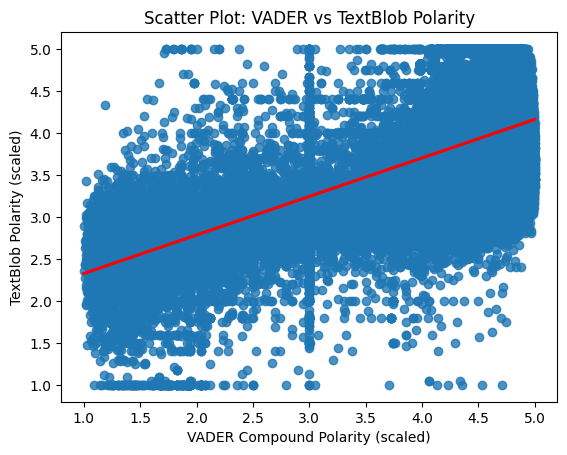

In [45]:
# Compute Pearson correlation between VADER and TextBlob scaled polarity
pearson_r, p_value = pearsonr(
    dataset["content_polarity_vader_compound_scaled"],
    dataset["content_polarity_textblob_polarity_scaled"]
)
print(f"Pearson R between VADER and TextBlob: {pearson_r:.3f}")

# Scatter plot with regression line
sns.regplot(
    data=dataset,
    x="content_polarity_vader_compound_scaled",
    y="content_polarity_textblob_polarity_scaled",
    line_kws={"color": "red"}
)
plt.xlabel("VADER Compound Polarity (scaled)")
plt.ylabel("TextBlob Polarity (scaled)")
plt.title("Scatter Plot: VADER vs TextBlob Polarity")
plt.show()

Pearson R between VADER and TextBlob: 0.770


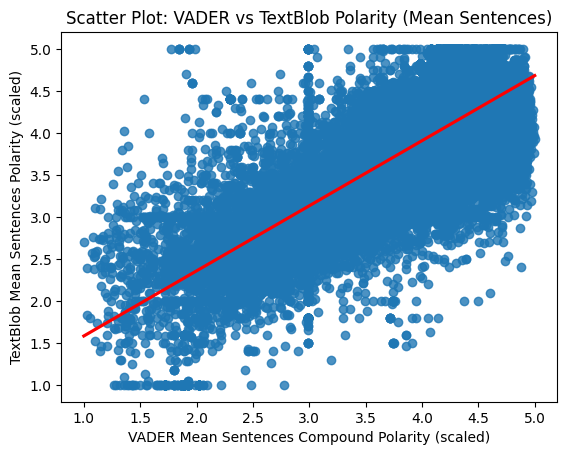

In [49]:
# Compute Pearson correlation between VADER and TextBlob scaled polarity
pearson_r, p_value = pearsonr(
    dataset["mean_sentence_polarity_vader_compound_scaled"],
    dataset["mean_sentence_polarity_textblob_polarity_scaled"]
)
print(f"Pearson R between VADER and TextBlob: {pearson_r:.3f}")

# Scatter plot with regression line
sns.regplot(
    data=dataset,
    x="mean_sentence_polarity_vader_compound_scaled",
    y="mean_sentence_polarity_textblob_polarity_scaled",
    line_kws={"color": "red"}
)
plt.xlabel("VADER Mean Sentences Compound Polarity (scaled)")
plt.ylabel("TextBlob Mean Sentences Polarity (scaled)")
plt.title("Scatter Plot: VADER vs TextBlob Polarity (Mean Sentences)")
plt.show()

In [ ]:
# Select columns for correlation
corr_cols = [
    "stars_scaled",
    "content_polarity_vader_compound_scaled",
    "content_polarity_vader_pos_scaled",
    "content_polarity_vader_neg_scaled",
    "content_polarity_vader_neu_scaled",
    "mean_sentence_polarity_vader_compound_scaled",
    "content_polarity_textblob_polarity_scaled",
    "mean_sentence_polarity_textblob_polarity_scaled"
]

# Compute correlation matrix
corr_matrix = dataset[corr_cols].corr()

# Mask the upper triangle
mask = np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
corr_masked = corr_matrix.mask(mask)

# Plot interactive heatmap
fig = px.imshow(
    corr_masked.values,
    x=corr_matrix.columns,
    y=corr_matrix.columns,
    color_continuous_scale=ColorPalette.MAIN_PALLETE,
    text_auto=".2f",
    aspect="auto"
)

fig.update_layout(
    title="Correlation Matrix (Upper Triangle Only): Sentiment Features vs Star Ratings",
    xaxis_title="Features",
    yaxis_title="Features",
    width=800,
    height=800
)

fig.show()

<font color='#BFD72F'>**Visualization Analysis**</font>

This correlation matrix reveals how various sentiment analysis features relate to user star ratings. Key insights include:

<font color='#BFD72F'>Correlation with Star Ratings</font>
- **Strong positive correlations**:
  - `content_polarity_vader_compound_scaled` (0.68)
  - `mean_sentence_polarity_vader_compound_scaled` (0.67)
  - `content_polarity_textblob_polarity_scaled` (0.63)
  - `mean_sentence_polarity_textblob_polarity_scaled` (0.61)
  - `content_polarity_vader_pos_scaled` (0.55)

- **Strong negative correlations**:
  - `content_polarity_vader_neg_scaled` (-0.51)
  - `content_polarity_vader_neu_scaled` (-0.39)

These results suggest that **positive sentiment scores (especially compound and polarity metrics)** are good predictors of higher ratings, while **negative and neutral sentiment scores** tend to correlate with lower ratings.

<font color='#BFD72F'>Inter-feature Relationships</font>
- **TextBlob and VADER compound scores** are highly correlated (up to 0.77 between mean sentence scores), indicating consistency across sentiment tools.
- `content_polarity_vader_pos_scaled` and `content_polarity_vader_neu_scaled` show a strong negative correlation (-0.93), reflecting their inverse roles in sentiment distribution.
- Negative sentiment (`vader_neg`) has weak correlation with neutral sentiment (`vader_neu`: 0.03), suggesting they capture distinct emotional tones.


<font color='#BFD72F'>Key Takeaways</font>
- **Compound polarity scores (VADER and TextBlob)** are the most reliable indicators of user satisfaction.
- **Mean sentence-level polarity** enhances predictive power, likely due to smoothing out local sentiment fluctuations.
- **Neutral sentiment** may dilute emotional intensity and is negatively associated with high ratings.
- **VADER’s positive and negative components** offer complementary signals but should be interpreted in tandem with compound scores.

This analysis supports using compound and polarity metrics—especially averaged at the sentence level—for modeling or predicting review ratings.

In [50]:
# Define comparisons using scaled columns
comparisons = {
    "VADER VS Stars": ("content_polarity_vader_compound_scaled", "stars_scaled"),
    "VADER (mean sentences) VS Stars": ("mean_sentence_polarity_vader_compound_scaled", "stars_scaled"),
    "TextBlob VS Stars": ("content_polarity_textblob_polarity_scaled", "stars_scaled"),
    "TextBlob (mean sentences) VS Stars": ("mean_sentence_polarity_textblob_polarity_scaled", "stars_scaled"),
    "VADER vs TextBlob": ("content_polarity_vader_compound_scaled", "content_polarity_textblob_polarity_scaled")
}

metrics = {}

# Compute metrics using compute_metrics()
for name, (pred_col, true_col) in comparisons.items():
    y_pred = dataset[pred_col]
    y_true = dataset[true_col]

    metrics[name] = compute_metrics(y_true, y_pred)

# Convert to DataFrame
metrics_df = pd.DataFrame(metrics)
metrics_df

,VADER VS Stars,VADER (mean sentences) VS Stars,TextBlob VS Stars,TextBlob (mean sentences) VS Stars,VADER vs TextBlob
Pearson R,0.677,0.671,0.634,0.614,0.634
RMSE,1.067,1.176,1.182,1.227,0.854
MAPE,0.213,0.261,0.258,0.270,0.159


<font color='#BFD72F'>**Impact of Preprocessing on TextBlob vs. VADER Performance**</font>

The lower correlation observed for TextBlob may help explain why it performs worse than VADER in our analysis. Because the dataset underwent minimal preprocessing, the text still contains noise such as punctuation, capitalization, informal expressions, repeated characters, and other linguistic cues. 

VADER is specifically designed to handle this type of noise and adjust sentiment scores accordingly, making it more robust in real-world, unprocessed text. 

In contrast, TextBlob relies on a simpler lexicon-based method and does not effectively account for these nuances. 

As a result, noisy or unstructured text tends to distort TextBlob’s polarity estimates, leading to overly smoothed sentiment values and poorer overall performance.

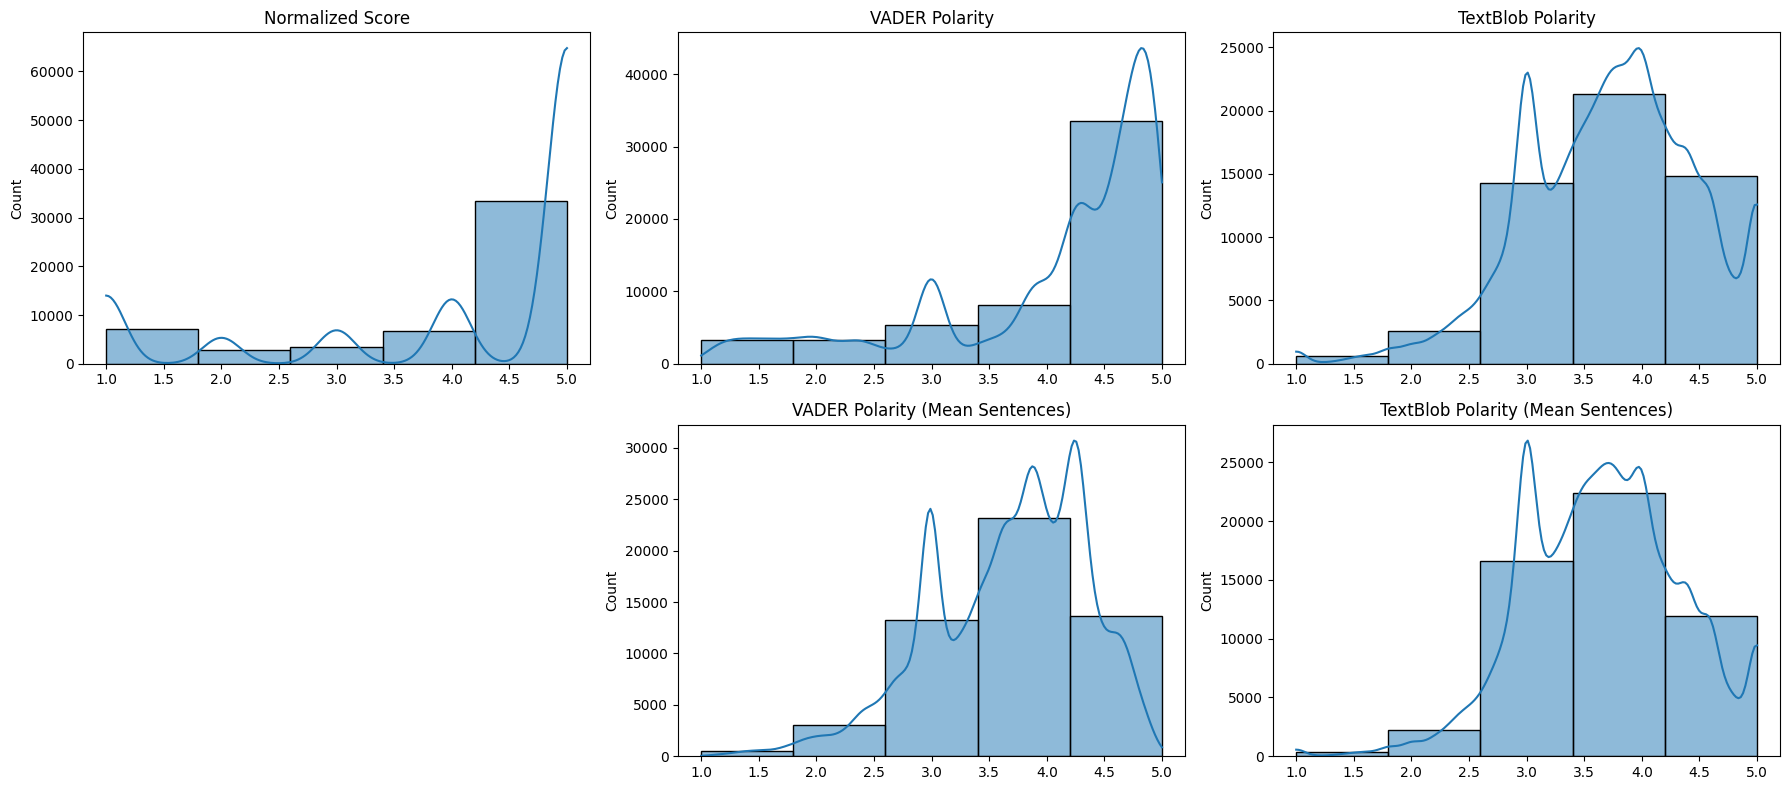

In [51]:
# Define columns and titles
cols_titles = [
    ("stars_scaled", "Normalized Score"),
    ("content_polarity_vader_compound_scaled", "VADER Polarity"),
    ("content_polarity_textblob_polarity_scaled", "TextBlob Polarity"),
    ("mean_sentence_polarity_vader_compound_scaled", "VADER Polarity (Mean Sentences)"),
    ("mean_sentence_polarity_textblob_polarity_scaled", "TextBlob Polarity (Mean Sentences)")
]

# Create a 2x3 grid
fig, axes = plt.subplots(2, 3, figsize=(18, 8))
axes = axes.flatten()  # flatten to 1D, always safe

# Index of the subplot to leave empty (bottom-left in 2x3 grid)
empty_index = 3

# Prepare axes to plot (skip the empty one)
axes_to_use = [ax for i, ax in enumerate(axes) if i != empty_index]

# Plot the histograms
for ax, (col, title) in zip(axes_to_use, cols_titles):
    sns.histplot(dataset[col], kde=True, bins=5, ax=ax)
    ax.set_title(title)
    ax.set_xlabel("")
    ax.set_ylabel("Count")

# Turn off the empty subplot
axes[empty_index].axis("off")

plt.tight_layout()
plt.show()

<font color='#BFD72F'>**Visualization Analysis**</font>

This visualization is crucial for comparing **how different sentiment analysis methods align with the actual distribution of user ratings**. 

By examining the **histograms and KDE curves**, we can assess whether VADER or TextBlob—at both content and sentence levels—produce sentiment scores that resemble the normalized star ratings. This helps identify which method best captures the underlying emotional tone reflected in user feedback and may be more suitable for predictive modeling or interpretability.

## <font color='#BFD72F' size=6>3.4 Answer the Question</font> <a class="anchor" id="3_4"></a>
  
[Back to TOC](#toc)

**How strong is the relationship between the polarity of a comments and its score?**

*(Sentiment Analysis with Correlation Matrix)*

Based on our analysis, **Vader** shows a slightly stronger correlation with review scores compared to TextBlob. 

Therefore, we focus on the correlation between the Vader polarity when applied to the **entire review** (rather than individual sentences) and its corresponding star rating, which makes sense as the majority of reviews have 1 or 2 sentences  

- **Pearson correlation (R):** 0.677  
- **RMSE:** 1.067  
- **MAPE:** 0.213

While the correlation is moderate—not exceptionally strong—it still reflects a **clear trend**:  
> More positive comments tend to receive higher star ratings.

The distribution plots support this observation. VADER polarity scores, when applied to full reviews, show a consistent alignment with normalized star ratings. This suggests that>
> VADER effectively captures the overall sentiment direction, even if it doesn't account for all the variability in user ratings.

In summary, VADER offers a reliable signal for sentiment analysis in short-form reviews, making it a suitable choice for predicting user satisfaction.

However, for more nuanced or longer-form reviews, combining VADER with other models or features (e.g., review length, subjectivity, or topic modeling) may yield better predictive performance.